# Business Impact — Oportunidades e Iniciativas

## Objetivo

Traducir los hallazgos de los análisis anteriores en oportunidades 
de negocio concretas con propuestas de acción justificadas por datos.

## Fuentes de este notebook

| Hallazgo | Notebook de origen |
|---|---|
| Retención crítica en período 1 y estacionalidad | 02_cohorts_sales |
| Mercados internacionales con alto ticket promedio | 02_cohorts_sales |
| Drop en funnel view → addtocart | 01_eda (Retailrocket) |
| Vocabulario de insatisfacción en reseñas negativas | 03_nlp_sentiment |
| Predictores de recompra (SHAP) | 05_predictive_model |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

OUTPUTS_DIR   = os.path.join('..', 'outputs')
ECOMMERCE_PATH = os.path.join('..', 'data', 'eCommerce_Dataset.csv')

df_ecom = pd.read_csv(ECOMMERCE_PATH, encoding='ISO-8859-1')
cancelled = df_ecom['InvoiceNo'].str.startswith('C')
df_clean = (
    df_ecom.drop_duplicates()
    .loc[~cancelled & (df_ecom['Quantity'] > 0) & (df_ecom['UnitPrice'] > 0)]
    .copy()
)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_customers = df_clean.dropna(subset=['CustomerID']).copy()
df_customers['CustomerID'] = df_customers['CustomerID'].astype(int)

print(f"df_clean:     {df_clean.shape}")
print(f"df_customers: {df_customers.shape}")

df_clean:     (524878, 9)
df_customers: (392692, 9)


---
## Oportunidad 1: Programa de retención temprana

El análisis de cohortes mostró que ninguna cohorte supera el 37% 
de retención en el período 1. El drop más pronunciado del ciclo 
de vida del cliente ocurre en el primer mes post-compra. 
Recuperar una fracción de esos clientes tiene impacto directo 
en el revenue de largo plazo.

### Cuantificación

In [2]:
df_customers['month'] = df_customers['InvoiceDate'].dt.to_period('M')

cohort_map = (
    df_customers.groupby('CustomerID')['month']
    .min().rename('cohort')
)
df_customers = df_customers.join(cohort_map, on='CustomerID')
df_customers['period'] = (df_customers['month'] - df_customers['cohort']).apply(lambda x: x.n)

cohort_size = df_customers[df_customers['period'] == 0].groupby('cohort')['CustomerID'].nunique()
period1     = df_customers[df_customers['period'] == 1].groupby('cohort')['CustomerID'].nunique()

retention_p1 = (period1 / cohort_size).fillna(0)
lost_p1      = cohort_size - period1.reindex(cohort_size.index).fillna(0)

avg_revenue_per_customer = df_customers.groupby('CustomerID')['revenue'].sum().mean()

print(f"Clientes perdidos en período 1 por cohorte:")
print(pd.DataFrame({'cohort_size': cohort_size, 
                    'retained_p1': period1,
                    'lost_p1': lost_p1.astype(int),
                    'retention_rate': retention_p1.round(3)}))
print(f"\nRevenue promedio por cliente (histórico): £{avg_revenue_per_customer:,.2f}")
print(f"Clientes totales perdidos en período 1:   {lost_p1.sum():.0f}")
print(f"Revenue potencial (recuperar 10%):        £{lost_p1.sum() * avg_revenue_per_customer * 0.10:,.0f}")

Clientes perdidos en período 1 por cohorte:
         cohort_size  retained_p1  lost_p1  retention_rate
cohort                                                    
2010-12          885        324.0      561           0.366
2011-01          417         92.0      325           0.221
2011-02          380         71.0      309           0.187
2011-03          452         68.0      384           0.150
2011-04          300         64.0      236           0.213
2011-05          284         54.0      230           0.190
2011-06          242         42.0      200           0.174
2011-07          188         34.0      154           0.181
2011-08          169         35.0      134           0.207
2011-09          299         70.0      229           0.234
2011-10          358         86.0      272           0.240
2011-11          323         36.0      287           0.111
2011-12           41          NaN       41           0.000

Revenue promedio por cliente (histórico): £2,048.69
Clientes totales p

### Visualización y propuesta de acción

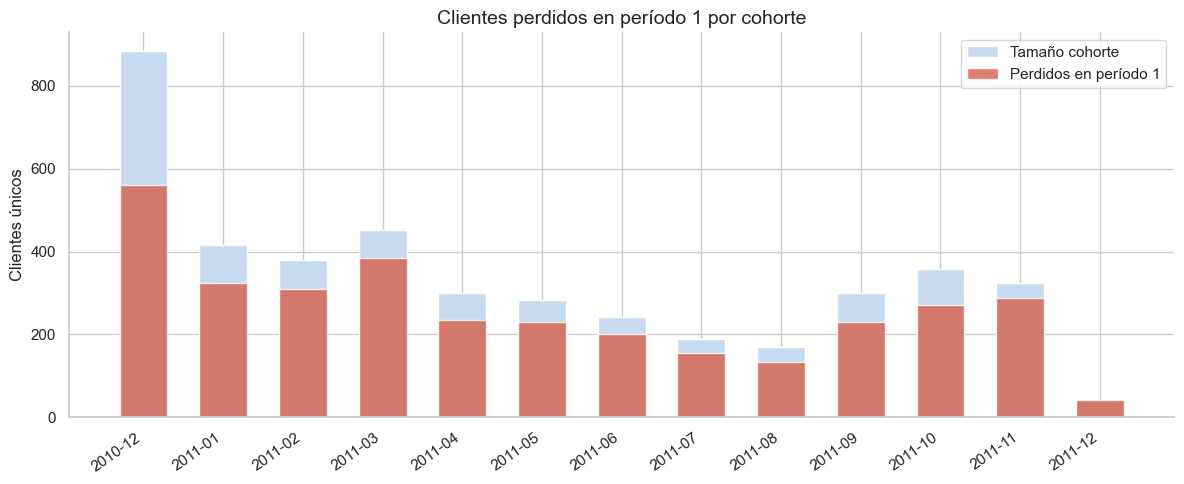

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(lost_p1))
ax.bar(x, cohort_size.values, label='Tamaño cohorte', color='#c6dbef', width=0.6)
ax.bar(x, lost_p1.values, label='Perdidos en período 1', color='#d6604d', width=0.6, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in cohort_size.index], rotation=35, ha='right')
ax.set_ylabel('Clientes únicos')
ax.set_title('Clientes perdidos en período 1 por cohorte')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'opp1_early_retention.png'), dpi=150, bbox_inches='tight')
plt.show()

### Propuesta de acción

**Programa de onboarding de 30 días para nuevos clientes.**

Activación: email automatizado a los 7 días post-primera compra 
con recomendaciones de productos basadas en la categoría de la 
compra inicial.

Segunda intervención: descuento de reactivación a los 25 días 
si no hubo segunda compra.

Justificación: el modelo predictivo identificó `days_since_last_order` 
como el segundo predictor más importante de recompra. Intervenir 
antes de que ese gap supere los 30 días maximiza la probabilidad 
de retención.

Métrica de éxito: tasa de retención en período 1 >= 30% 
en cohortes post-implementación (baseline actual: 11%–37%).

---
## Oportunidad 2: Expansión en mercados de alto valor

### Cuantificación

In [4]:
country_metrics = (
    df_clean
    .groupby('Country')
    .agg(
        revenue         = ('revenue', 'sum'),
        transactions    = ('InvoiceNo', 'nunique'),
        avg_order_value = ('revenue', 'mean')
    )
    .sort_values('avg_order_value', ascending=False)
    .reset_index()
)

uk_aov    = country_metrics.loc[country_metrics['Country'] == 'United Kingdom', 'avg_order_value'].values[0]
target_mkts = country_metrics[
    (country_metrics['Country'] != 'United Kingdom') &
    (country_metrics['avg_order_value'] > uk_aov * 3) &
    (country_metrics['transactions'] >= 10)
].copy()

target_mkts['aov_vs_uk'] = (target_mkts['avg_order_value'] / uk_aov).round(1)

print(f"AOV promedio UK: £{uk_aov:.2f}")
print(f"\nMercados con AOV > 3x UK y >= 10 transacciones:")
print(target_mkts[['Country', 'revenue', 'transactions', 'avg_order_value', 'aov_vs_uk']].to_string(index=False))

AOV promedio UK: £18.75

Mercados con AOV > 3x UK y >= 10 transacciones:
    Country   revenue  transactions  avg_order_value  aov_vs_uk
Netherlands 285446.34            94       121.003111        6.5
  Australia 138453.81            57       117.234386        6.3
      Japan  37416.37            19       116.561900        6.2
     Sweden  38367.83            36        85.261844        4.5


### Visualización y propuesta de acción

/var/folders/rr/b8q7zgq911j0wd35x_j_38940000gn/T/ipykernel_29867/377536687.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(top_intl['Country'], rotation=35, ha='right')


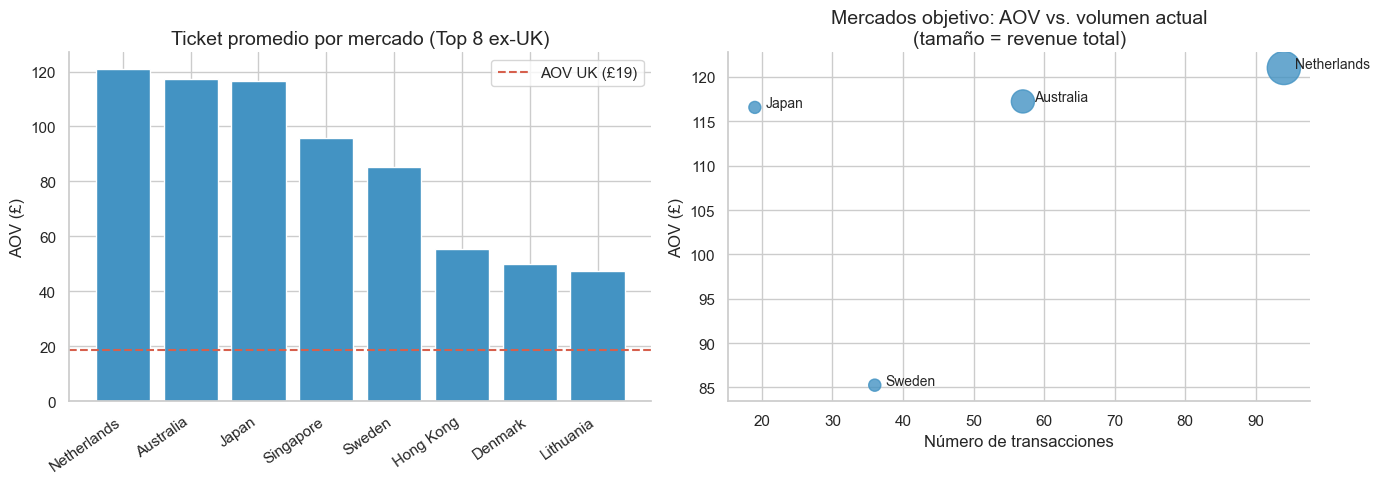

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_intl = country_metrics[country_metrics['Country'] != 'United Kingdom'].head(8)

axes[0].bar(top_intl['Country'], top_intl['avg_order_value'], color='#4393c3')
axes[0].axhline(y=uk_aov, color='#d6604d', linestyle='--', linewidth=1.5, label=f'AOV UK (£{uk_aov:.0f})')
axes[0].set_title('Ticket promedio por mercado (Top 8 ex-UK)')
axes[0].set_ylabel('AOV (£)')
axes[0].set_xticklabels(top_intl['Country'], rotation=35, ha='right')
axes[0].legend()

axes[1].scatter(target_mkts['transactions'], target_mkts['avg_order_value'],
                s=target_mkts['revenue']/500, color='#4393c3', alpha=0.8)
for _, row in target_mkts.iterrows():
    axes[1].annotate(row['Country'],
                     (row['transactions'], row['avg_order_value']),
                     textcoords='offset points', xytext=(8, 0), fontsize=10)
axes[1].set_xlabel('Número de transacciones')
axes[1].set_ylabel('AOV (£)')
axes[1].set_title('Mercados objetivo: AOV vs. volumen actual\n(tamaño = revenue total)')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'opp2_international_markets.png'), dpi=150, bbox_inches='tight')
plt.show()

### Propuesta de acción

**Campaña de expansión focalizada en Netherlands, Australia y Japan.**

Estos tres mercados comparten alto AOV (£116–£121 vs. £19 en UK) 
con volumen de transacciones bajo, lo que indica demanda existente 
no desarrollada.

Acción concreta: localización de la plataforma (moneda local, 
métodos de pag

## Oportunidad 3: Optimización del funnel de conversión

### Cuantificación

In [6]:
events = pd.read_csv(os.path.join('..', 'data', 'events.csv'))
events = events.drop_duplicates()

visitors_view = events[events['event']=='view']['visitorid'].nunique()
visitors_cart = events[events['event']=='addtocart']['visitorid'].nunique()
visitors_tx   = events[events['event']=='transaction']['visitorid'].nunique()

conv_view_cart = visitors_cart / visitors_view
conv_cart_tx   = visitors_tx / visitors_cart

print(f"Visitantes con al menos 1 view:        {visitors_view:,}")
print(f"Visitantes con al menos 1 addtocart:   {visitors_cart:,}  ({conv_view_cart:.2%})")
print(f"Visitantes con al menos 1 transaction: {visitors_tx:,}  ({visitors_tx/visitors_view:.2%})")
print(f"\nConversión view → addtocart:  {conv_view_cart:.2%}")
print(f"Conversión addtocart → tx:    {conv_cart_tx:.2%}")

mejora_escenario = 0.04
nuevos_compradores = int(visitors_view * mejora_escenario) - visitors_tx
print(f"\nEscenario: conversión end-to-end mejora de {visitors_tx/visitors_view:.2%} a {mejora_escenario:.2%}")
print(f"Nuevos compradores potenciales: {nuevos_compradores:,}")

Visitantes con al menos 1 view:        1,404,179
Visitantes con al menos 1 addtocart:   37,722  (2.69%)
Visitantes con al menos 1 transaction: 11,719  (0.83%)

Conversión view → addtocart:  2.69%
Conversión addtocart → tx:    31.07%

Escenario: conversión end-to-end mejora de 0.83% a 4.00%
Nuevos compradores potenciales: 44,448


### Visualización y propuesta de acción

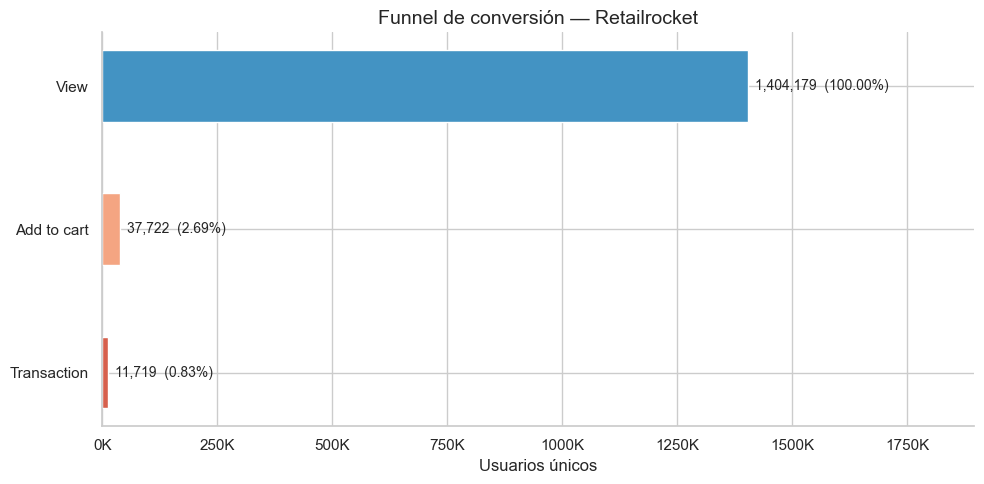

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

stages  = ['View', 'Add to cart', 'Transaction']
valores = [visitors_view, visitors_cart, visitors_tx]
colors  = ['#4393c3', '#f4a582', '#d6604d']

bars = ax.barh(stages, valores, color=colors, height=0.5)
for bar, val in zip(bars, valores):
    pct = val / visitors_view * 100
    ax.text(bar.get_width() + 15000, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.2f}%)', va='center', fontsize=10)

ax.set_xlabel('Usuarios únicos')
ax.set_title('Funnel de conversión — Retailrocket')
ax.set_xlim(0, visitors_view * 1.35)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'opp3_funnel.png'), dpi=150, bbox_inches='tight')
plt.show()

### Propuesta de acción

**Optimización de la página de producto para reducir el drop 
view → addtocart.**

El problema está en la etapa de consideración: solo el 2.69% de los 
visitantes que ven un producto lo agregan al carrito. Una vez en el 
carrito, el 31.07% completa la compra, lo que indica que el proceso 
de checkout no es el cuello de botella.

Acciones concretas:
- A/B testing de imágenes de producto y descripción en los ítems 
  con mayor ratio de vistas y menor conversión a carrito.
- Implementación de social proof (número de compras recientes, 
  reseñas visibles sin scroll) en la página de producto.
- Remarketing a usuarios que vieron un producto 3 o más veces 
  sin agregar al carrito (señal de intención alta sin conversión).

Métrica de éxito: conversión view → addtocart >= 4% 
en páginas intervenidas (baseline actual: 2.69%).

---
## Resumen ejecutivo

| # | Oportunidad | Métrica actual | Potencial cuantificado |
|---|---|---|---|
| 1 | Retención temprana | 11%–37% retención período 1 | £688K revenue recuperable (10% de clientes perdidos) |
| 2 | Expansión internacional | 94 transacciones en mercados objetivo | AOV 6x UK en Netherlands, Australia, Japan |
| 3 | Optimización de funnel | 0.83% conversión end-to-end | 44.448 compradores adicionales a 4% conversión |